### IMPORTING DATASET


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### IMPORTING DATA

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
print(f'Titanic dataset: \n{df.head()}')

Titanic dataset: 
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500  

### DATA MANIPULATION AND DATA CLEANING

DATAFRAME INFORMATION

In [3]:
print(df.shape)
print(f'\n {df.info()}')

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB

 None


CHECKING FOR NULL VALUES

In [4]:
null_values =df.isnull().sum()
print(f'Null values in each column:\n{null_values}')

Null values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


HANDLING MISSING VALUES

In [5]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

DROPPING COLUMNS

In [6]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

## BASIC Exploratory Data Analysis


Number of passenger gender wise:
Sex
male      577
female    314
Name: count, dtype: int64


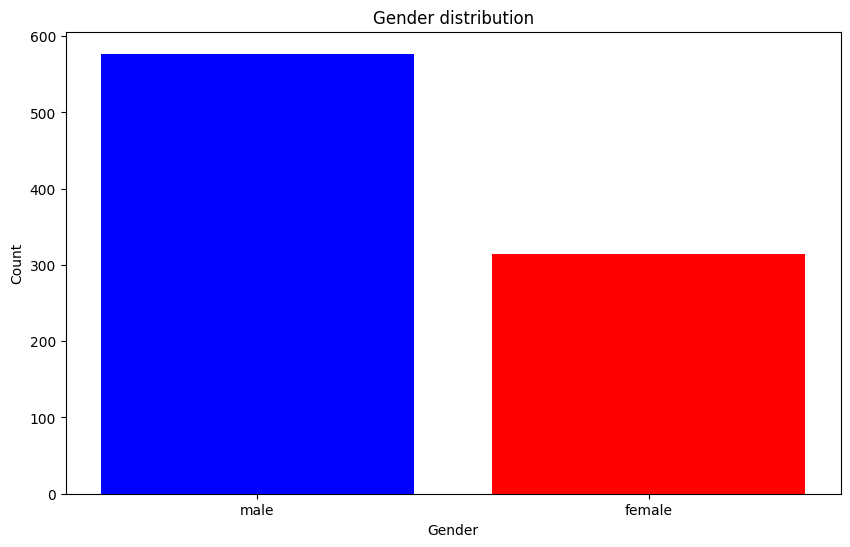

In [7]:
gender_count = df['Sex'].value_counts()
print(f'Number of passenger gender wise:\n{gender_count}')
plt.figure(figsize=(10,6))
plt.bar(gender_count.index,gender_count.values,color=['blue','red'])
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

Number of passenger class wise:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


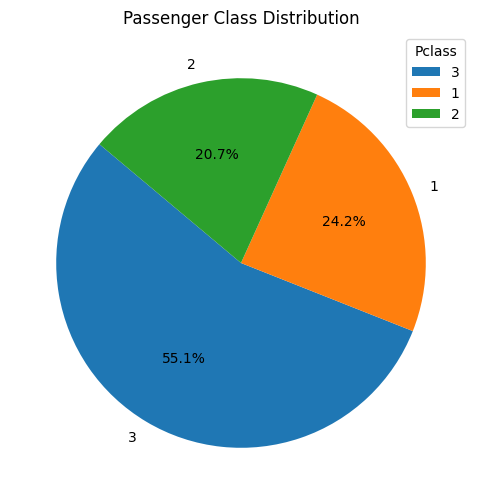

In [8]:
pclass_count = df['Pclass'].value_counts()
print(f'Number of passenger class wise:\n{pclass_count}')
plt.figure(figsize=(10,6))
plt.pie(pclass_count.values,labels=pclass_count.index,autopct='%1.1f%%',startangle=140)
plt.title('Passenger Class Distribution')
plt.legend(title='Pclass')
plt.show()

Number of passenger survived :
Survived
0    549
1    342
Name: count, dtype: int64


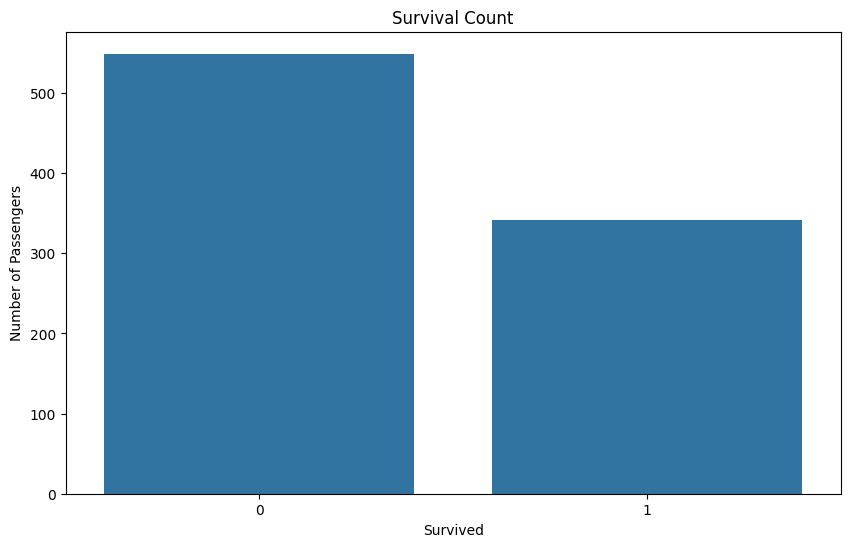

In [9]:
survived_count = df['Survived'].value_counts()
print(f'Number of passenger survived :\n{survived_count}')
plt.figure(figsize=(10,6))
sns.countplot(x='Survived',data=df)
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.title('Survival Count')
plt.show()

## SURVIVAL PREDICTION MODEL;


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

print("\n--- Building Prediction Model ---\n")

# Fix missing values properly
df['Embarked'] = df['Embarked'].fillna('S')

# Encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Feature Engineering (simple but effective)
df['FamilySize'] = df['SibSp'] + df['Parch']
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

# Define X and y
y = df['Survived']
X = df.drop(columns=['Survived'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy*100:.2f}%\n')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred), "\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


--- Building Prediction Model ---

Model Accuracy: 79.89%

Confusion Matrix:
[[89 16]
 [20 54]] 

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### MODEL INSIGHTS
- The Logistic Regression model achieved an accuracy of around 80%, showing good predictive performance.
- The model performs slightly better at predicting non-survivors than survivors.
- Gender and passenger class were key factors influencing survival outcomes.